# DCF Valuation Tool
### Automated intrinsic value estimator

This notebook builds a full discounted cash flow (DCF) model for Apple Inc (AAPL) using live financial model data from FMP API

**The model covers:**
- Fetching and structuring the 3 core financial statements
- Linking the statements together (the 3-statemenet model)
- Projecting free cash flow over 5 years
- Calculating WACC (Weighted Average Cost of Capital)
- Discounting cash flows to arrive at an intrinsic value per share
- Sensitivity analysis across different WACC and growth assumptions

In [3]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from config import FMP_API_KEY

In [4]:
BASE = "https://financialmodelingprep.com/stable"
TICKER = "AAPL"

def fetch(endpoint):
    url = f"{BASE}/{endpoint}?symbol={TICKER}&period=FY&limit=5&apikey={FMP_API_KEY}"
    return requests.get(url).json()

income = fetch("income-statement")
balance = fetch("balance-sheet-statement")
cashflow = fetch("cash-flow-statement")

print("Data fetched successfully") 

Data fetched successfully


## The 3-Statement Model

The foundation of any corporate valuation is understanding how the three core financial statements connect:

- **Income statement -> Balance sheet:** Net income flows into retained earnings, which is part of shareholders' equity on the balance sheet
- **Income statement -> Cash flow statement:** Net income is the starting point of the operating cash flow section. Non-cash items like deprecation are then added back
- **Cash flow statement -> Balance sheet:** Capital expenditure reduces cash on the balance sheet and increases fixed assets. The ending cash balance on the cash flow statement matches the cash line on the balance sheet.

These linkages matter because a standalone income statement can be misleading — a company can show strong profits while actually end up burning cash. The 3-statement model reveals the full picture.

In [6]:
df_inc = pd.DataFrame(income)[["date", "revenue", "netIncome", "ebitda", "depreciationAndAmortization"]]
df_bal = pd.DataFrame(balance)[["date", "totalAssets", "retainedEarnings", "totalDebt", "cashAndCashEquivalents"]]
df_cf = pd.DataFrame(cashflow)[["date", "operatingCashFlow", "capitalExpenditure", "freeCashFlow"]]

print("=== Income Statement ===")
display(df_inc)
print("\n=== Balance Sheet ===")
display(df_bal)
print("\n=== Cash Flow Statement ===")
display(df_cf)

=== Income Statement ===


,date,revenue,netIncome,ebitda,depreciationAndAmortization
0,2025-09-27,416161000000,112010000000,144427000000,11698000000
1,2024-09-28,391035000000,93736000000,134930000000,11445000000
2,2023-09-30,383285000000,96995000000,129188000000,11519000000
3,2022-09-24,394328000000,99803000000,133138000000,11104000000
4,2021-09-25,365817000000,94680000000,123136000000,11284000000



=== Balance Sheet ===


,date,totalAssets,retainedEarnings,totalDebt,cashAndCashEquivalents
0,2025-09-27,359241000000,-14264000000,112377000000,35934000000
1,2024-09-28,364980000000,-19154000000,119059000000,29943000000
2,2023-09-30,352583000000,-214000000,123930000000,29965000000
3,2022-09-24,352755000000,-3068000000,132480000000,23646000000
4,2021-09-25,351002000000,5562000000,136522000000,34940000000



=== Cash Flow Statement ===


,date,operatingCashFlow,capitalExpenditure,freeCashFlow
0,2025-09-27,111482000000,-12715000000,98767000000
1,2024-09-28,118254000000,-9447000000,108807000000
2,2023-09-30,110543000000,-10959000000,99584000000
3,2022-09-24,122151000000,-10708000000,111443000000
4,2021-09-25,104038000000,-11085000000,92953000000


## Free Cash Flow Projection

Free cash flow (FCF) is the cash a company generates after accounting for capital expenditure. It is the metric we discount in a DCF model because it represents cash that could theoretically be returned to shareholders.

**Projection Assumptions:**
- Uses a 5-year projection horizon, which is standard for DCF models
- The growth rate is based on Apple's historical FCF growth, cross-referenced with analyst consensus estimates
- A conservative 6% annual growth rate is applied, reflecting Apple's maturing but still growing business

In [7]:
fcf_hist = df_cf["freeCashFlow"].values[::-1].astype(float)
growth_rate = 0.06

fcf_proj = []
last_fcf = fcf_hist[-1]

for i in range(1, 6):
    last_fcf = last_fcf * (1 + growth_rate)
    fcf_proj.append(last_fcf)

proj_df = pd.DataFrame({
    "Year": [f"Year {i}" for i in range (1, 6)],
    "Projected FCF ($)": [f"${v:,.0f}" for v in fcf_proj]
})

display(proj_df)

,Year,Projected FCF ($)
0,Year 1,"$104,693,020,000"
1,Year 2,"$110,974,601,200"
2,Year 3,"$117,633,077,272"
3,Year 4,"$124,691,061,908"
4,Year 5,"$132,172,525,623"


## WACC — Weighted Average Cost of Capital

WACC is the rate used to discount future cash flows back into today's value. It represents the blended cost of funding a company through both equity and debt.

**Formula:** WACC = (E/V x Cost of Equity) + (D/V x Cost of Debt x (1 - Tax Rate))

**Assumptions used:**
- **Cost of equity (9%):** Estimated using the Capital Asset Pricing Model (CAPM) — risk-free rate of ~4.5% plus Apple's beta (~1.2%) multiplied by an equity risk premium of ~5.5%
- **Cost of debt (4%):** Approximation of Apple's effective interest rate on outstanding debt
- **Tax rate (21%):** US federal corporate tax rate
- **Debt and equity weights:** Derived from Apple's most recent balance sheet

In [8]:
cost_of_equity = 0.09
cost_of_debt = 0.04
tax_rate = 0.21

equity = float(df_bal["totalAssets"].iloc[0]) - float(df_bal["totalDebt"].iloc[0])
debt = float(df_bal["totalDebt"].iloc[0])
total = equity + debt

wacc = (equity / total * cost_of_equity) + (debt / total * cost_of_debt * (1 - tax_rate))

print(f"Equity Weight: {equity/total:.1%}")
print(f"Debt Weight:   {debt/total:.1%}")
print(f"WACC:          {wacc:.2%}")

Equity Weight: 68.7%
Debt Weight:   31.3%
WACC:          7.17%


## DCF Valuation

With projected free cash flows and a discounted rate in hand, the intrinsic value of Apple's equity can now be calculated.

**Method**
1. Discount each of the 5 projected DCFs back to present value using WACC
2. Calculate a terminal value — the value of all cash flows beyond year 5, assuming a long-run growth rate equal to roughly nominal GDP growth (2.5%)
3. Sum up the present values and the terminal value to get the enterprise value
4. Subtract net debt and divide by outstanding shares to arrive at intrinsic value per share

The result is then compared to Apple's current market price to assess whether the stock appears over or undervalued under these assumptions.

In [9]:
terminal_growth = 0.025
shares_outstanding = 15_550_000_000

pv_fcfs = sum([fcf / (1 + wacc)**i for i, fcf in enumerate(fcf_proj, 1)])
terminal_value = (fcf_proj[-1] * (1 + terminal_growth)) / (wacc - terminal_growth)
pv_terminal = terminal_value / (1 + wacc)**5

enterprise_value = pv_fcfs + pv_terminal
intrinsic_value = enterprise_value / shares_outstanding

print(f"PV of projected FCFs:  ${pv_fcfs:>15,.0f}")
print(f"PV of terminal value:  ${pv_terminal:>15,.0f}")
print(f"Enterprise value:      ${enterprise_value:>15,.0f}")
print(f"\nIntrinsic value per share: ${intrinsic_value:.2f}")

PV of projected FCFs:  $477,852,831,478
PV of terminal value:  $2,050,340,861,811
Enterprise value:      $2,528,193,693,288

Intrinsic value per share: $162.58


## Sensitivity Analysis

A single DCF output is only as reliable as its assumptions. Small changes to WACC or the terminal growth rate can significantly shift the intrinsic value estimate.

The table below shows intrinsic value per share across a range of WACC values (columns) and terminal growth rates (rows). The central cell reflects the base case assumptions.

This kind of sensitivity analysis is standard practice in professional valuation work — it communicates not just a single number, but a reasonable range of outcomes.

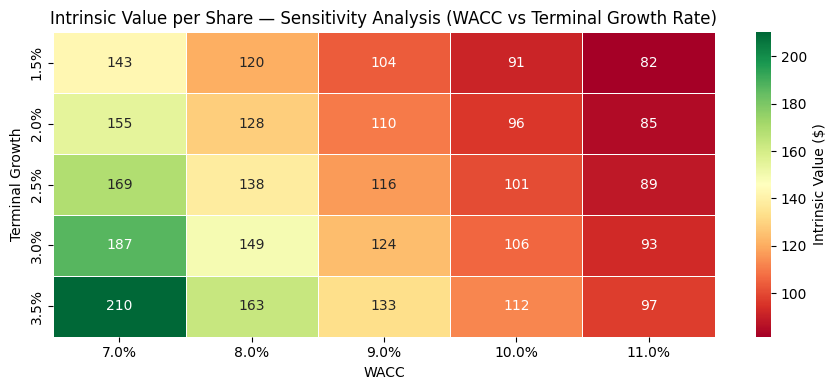

In [13]:
waccs = [0.07, 0.08, 0.09, 0.10, 0.11]
growths = [0.015, 0.020, 0.025, 0.030, 0.035]

table = []
for g in growths:
    row = []
    for w in waccs:
        tv = (fcf_proj[-1] * (1 + g)) / (w - g)
        pv = sum([f / (1 + w)**i for i, f in enumerate(fcf_proj, 1)]) + tv / (1 + w)**5
        row.append(round(pv / shares_outstanding, 2))
    table.append(row)

df_sens = pd.DataFrame(
    table,
    index=[f"{g*100:.1f}%" for g in growths],
    columns=[f"{w*100:.1f}%" for w in waccs]
)
df_sens.index.name = "Terminal Growth"

plt.figure(figsize=(9, 4))
sns.heatmap(df_sens, annot=True, fmt=".0f", cmap="RdYlGn", linewidths=0.5, cbar_kws={"label": "Intrinsic Value ($)"})
plt.title("Intrinsic Value per Share — Sensitivity Analysis (WACC vs Terminal Growth Rate)", fontsize=12)
plt.xlabel("WACC")
plt.tight_layout()
plt.show()